In [1]:
pip install numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# import os

# # Go up one level to the project root
# os.chdir('..')  # '..' means "go up one folder"

# # Verify you're in the right place
# print("Current directory:", os.getcwd())
# #print("\nContents:")
# for item in os.listdir('.'):
#     print(f"  - {item}")

# Now this should work:
import pandas as pd
df = pd.read_csv("/Users/srivanur/Documents/fedpoi_thesis/data/raw/dataset_TSMC2014_NYC.csv", sep="\t")
print("\n✓ Dataset loaded successfully!")


✓ Dataset loaded successfully!


In [3]:
# 01_explore_data.py - Your First Script!

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the Foursquare dataset
print("Loading Foursquare NYC dataset...")

# If you downloaded from Kaggle:
df = pd.read_csv('/Users/srivanur/Documents/fedpoi_thesis/data/raw/dataset_TSMC2014_NYC.csv', sep=',')


print("✓ Dataset loaded successfully!")
print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Display first few rows
print("\n" + "="*50)
print("First 5 check-ins:")
print("="*50)
print(df.head())

# Basic statistics
print("\n" + "="*50)
print("BASIC STATISTICS:")
print("="*50)
print(f"Total check-ins: {len(df):,}")
print(f"Unique users: {df['userId'].nunique():,}")
print(f"Unique venues: {df['venueId'].nunique():,}")
print(f"Unique categories: {df['venueCategory'].nunique():,}")

# Date range
print(f"\nDate range: {df['utcTimestamp'].min()} to {df['utcTimestamp'].max()}")

# User activity distribution
print("\n" + "="*50)
print("USER ACTIVITY:")
print("="*50)
user_checkins = df.groupby('userId').size()
print(f"Average check-ins per user: {user_checkins.mean():.1f}")
print(f"Median check-ins per user: {user_checkins.median():.1f}")
print(f"Max check-ins by one user: {user_checkins.max()}")
print(f"Min check-ins by one user: {user_checkins.min()}")

# Top 5 most popular venues
print("\n" + "="*50)
print("TOP 5 MOST POPULAR VENUES:")
print("="*50)
top_venues = df.groupby(['venueId', 'venueCategory']).size().sort_values(ascending=False).head(5)
for (venue, category), count in top_venues.items():
    print(f"{venue} ({category}): {count} check-ins")

# Top 5 most popular categories
print("\n" + "="*50)
print("TOP 5 VENUE CATEGORIES:")
print("="*50)
top_categories = df['venueCategory'].value_counts().head(5)
for category, count in top_categories.items():
    print(f"{category}: {count} check-ins")

print("\n✓ Exploration complete!")
print("\nYour dataset is ready for federated learning!")

Loading Foursquare NYC dataset...
✓ Dataset loaded successfully!

Dataset shape: (227428, 8)
Columns: ['userId', 'venueId', 'venueCategoryId', 'venueCategory', 'latitude', 'longitude', 'timezoneOffset', 'utcTimestamp']

First 5 check-ins:
   userId                   venueId           venueCategoryId  \
0     470  49bbd6c0f964a520f4531fe3  4bf58dd8d48988d127951735   
1     979  4a43c0aef964a520c6a61fe3  4bf58dd8d48988d1df941735   
2      69  4c5cc7b485a1e21e00d35711  4bf58dd8d48988d103941735   
3     395  4bc7086715a7ef3bef9878da  4bf58dd8d48988d104941735   
4      87  4cf2c5321d18a143951b5cec  4bf58dd8d48988d1cb941735   

         venueCategory   latitude  longitude  timezoneOffset  \
0  Arts & Crafts Store  40.719810 -74.002581            -240   
1               Bridge  40.606800 -74.044170            -240   
2       Home (private)  40.716162 -73.883070            -240   
3       Medical Center  40.745164 -73.982519            -240   
4           Food Truck  40.740104 -73.989658      

Creating Plot 1: User Activity Distribution...
✓ Saved: results/plots/01_user_activity.png
Creating Plot 2: Top Venue Categories...
✓ Saved: results/plots/02_top_categories.png
Creating Plot 3: Check-ins Timeline...


/var/folders/q2/9r7fhbb519j78v591gp5tm5m0000gp/T/ipykernel_80501/2559679244.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['timestamp'] = pd.to_datetime(df['utcTimestamp'])
/var/folders/q2/9r7fhbb519j78v591gp5tm5m0000gp/T/ipykernel_80501/2559679244.py:46: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['timestamp'].dt.to_period('M')


✓ Saved: results/plots/03_timeline.png
Creating Plot 4: Geographic Distribution...
✓ Saved: results/plots/04_geographic.png

✓ All visualizations created!
Check the 'results/plots/' folder


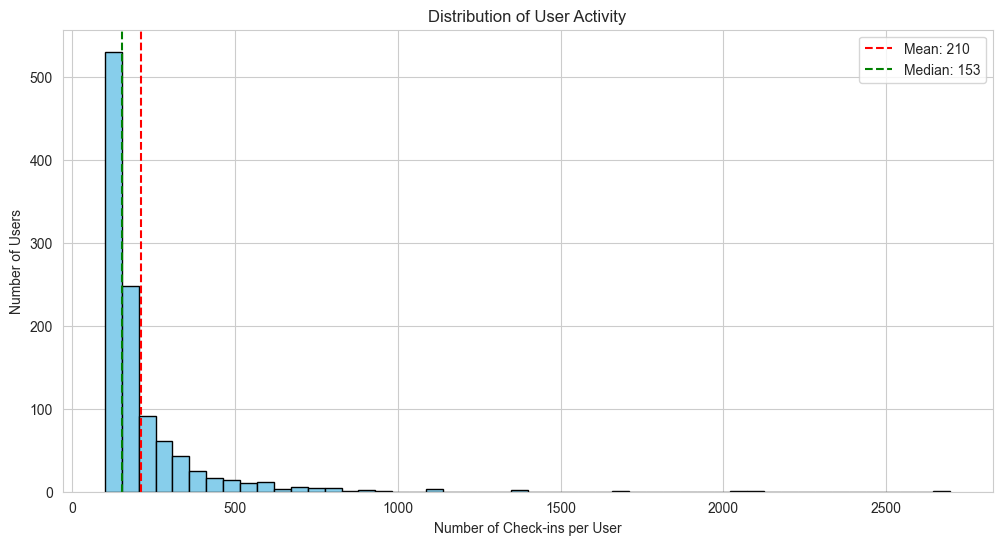

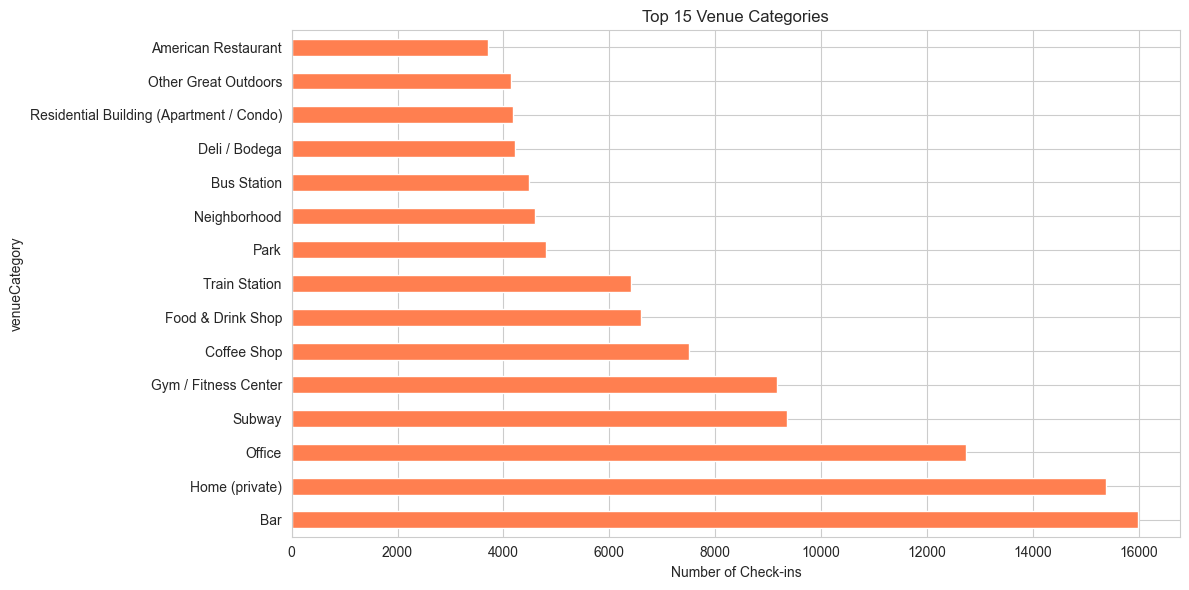

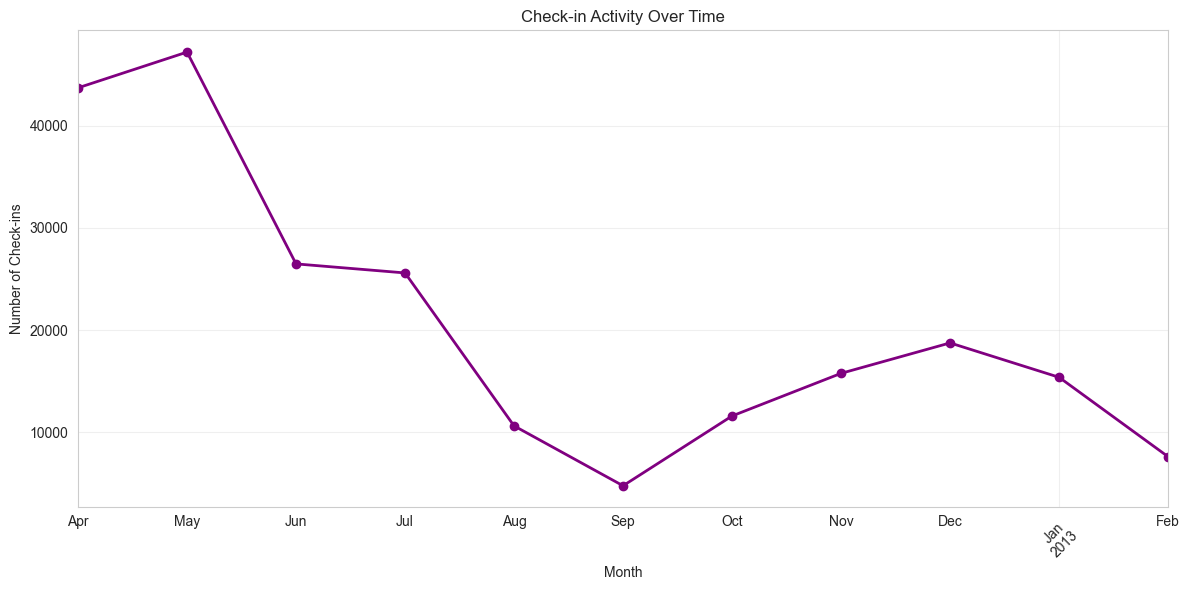

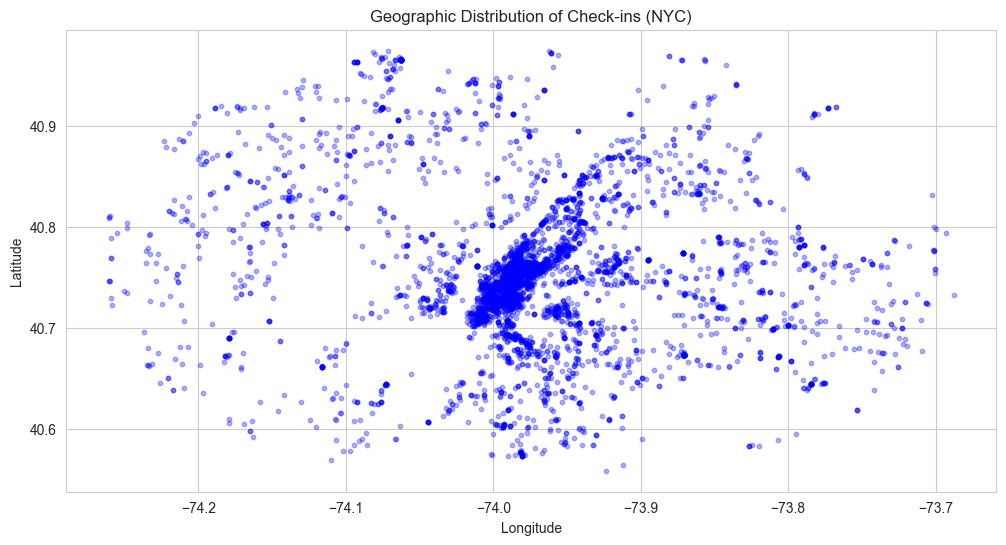

In [6]:
# 02_visualize_data.py - Visualize your data

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set nice style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
df = pd.read_csv('/Users/srivanur/Documents/fedpoi_thesis/data/raw/dataset_TSMC2014_NYC.csv', sep=',')

# Create results folder
import os
os.makedirs('results/plots', exist_ok=True)

# 1. User activity distribution
print("Creating Plot 1: User Activity Distribution...")
user_checkins = df.groupby('userId').size()
plt.figure()
plt.hist(user_checkins, bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Number of Check-ins per User')
plt.ylabel('Number of Users')
plt.title('Distribution of User Activity')
plt.axvline(user_checkins.mean(), color='red', linestyle='--', label=f'Mean: {user_checkins.mean():.0f}')
plt.axvline(user_checkins.median(), color='green', linestyle='--', label=f'Median: {user_checkins.median():.0f}')
plt.legend()
plt.savefig('results/plots/01_user_activity.png', dpi=300, bbox_inches='tight')
print("✓ Saved: results/plots/01_user_activity.png")

# 2. Top 15 categories
print("Creating Plot 2: Top Venue Categories...")
plt.figure()
top_cats = df['venueCategory'].value_counts().head(15)
top_cats.plot(kind='barh', color='coral')
plt.xlabel('Number of Check-ins')
plt.title('Top 15 Venue Categories')
plt.tight_layout()
plt.savefig('results/plots/02_top_categories.png', dpi=300, bbox_inches='tight')
print("✓ Saved: results/plots/02_top_categories.png")

# 3. Check-ins over time (by month)
print("Creating Plot 3: Check-ins Timeline...")
df['timestamp'] = pd.to_datetime(df['utcTimestamp'])
df['month'] = df['timestamp'].dt.to_period('M')
monthly_checkins = df.groupby('month').size()
plt.figure()
monthly_checkins.plot(kind='line', marker='o', color='purple', linewidth=2)
plt.xlabel('Month')
plt.ylabel('Number of Check-ins')
plt.title('Check-in Activity Over Time')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/plots/03_timeline.png', dpi=300, bbox_inches='tight')
print("✓ Saved: results/plots/03_timeline.png")

# 4. Geographic distribution (scatter plot)
print("Creating Plot 4: Geographic Distribution...")
plt.figure()
sample = df.sample(5000)  # Sample for faster plotting
plt.scatter(sample['longitude'], sample['latitude'], 
           alpha=0.3, s=10, c='blue')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Distribution of Check-ins (NYC)')
plt.savefig('results/plots/04_geographic.png', dpi=300, bbox_inches='tight')
print("✓ Saved: results/plots/04_geographic.png")

print("\n" + "="*50)
print("✓ All visualizations created!")
print("Check the 'results/plots/' folder")
print("="*50)

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Load data
df = pd.read_csv('/Users/srivanur/Documents/fedpoi_thesis/data/raw/dataset_TSMC2014_NYC.csv', sep=',')

print("Step 1: Filtering active users...")
# Keep users with at least 5 check-ins
user_counts = df.groupby('userId').size()
active_users = user_counts[user_counts >= 5].index
df_filtered = df[df['userId'].isin(active_users)]

print(f"Before filtering: {len(df)} check-ins")
print(f"After filtering: {len(df_filtered)} check-ins")
print(f"Users removed: {df['userId'].nunique() - df_filtered['userId'].nunique()}")

print("\nStep 2: Encoding IDs...")
# Encode UserIDs and VenueIDs to consecutive integers
user_encoder = LabelEncoder()
venue_encoder = LabelEncoder()

df_filtered['user_id_encoded'] = user_encoder.fit_transform(df_filtered['userId'])
df_filtered['venue_id_encoded'] = venue_encoder.fit_transform(df_filtered['venueId'])

print(f"Unique users: {df_filtered['user_id_encoded'].nunique()}")
print(f"Unique venues: {df_filtered['venue_id_encoded'].nunique()}")

print("\nStep 3: Creating interaction matrix...")
# Create user-venue interaction matrix (binary: 1 if visited, 0 otherwise)
interaction_matrix = pd.crosstab(
    df_filtered['user_id_encoded'],
    df_filtered['venue_id_encoded']
)

# Convert to binary (visited=1, not visited=0)
interaction_matrix = (interaction_matrix > 0).astype(int)

print(f"Matrix shape: {interaction_matrix.shape}")
print(f"Matrix sparsity: {100 * (1 - interaction_matrix.sum().sum() / (interaction_matrix.shape[0] * interaction_matrix.shape[1])):.2f}%")

print("\nStep 4: Saving processed data...")
# Save
df_filtered.to_csv('/Users/srivanur/Documents/fedpoi_thesis/data/processed/foursquare_filtered.csv', index=False)
interaction_matrix.to_csv('/Users/srivanur/Documents/fedpoi_thesis/data/processed/interaction_matrix.csv')

# Save encoders for later use
import pickle
with open('/Users/srivanur/Documents/fedpoi_thesis/data/processed/user_encoder.pkl', 'wb') as f:
    pickle.dump(user_encoder, f)
with open('/Users/srivanur/Documents/fedpoi_thesis/data/processed/venue_encoder.pkl', 'wb') as f:
    pickle.dump(venue_encoder, f)

print("\n✓ Data preprocessing complete!")
print("Saved files:")
print("  - data/processed/foursquare_filtered.csv")
print("  - data/processed/interaction_matrix.csv")
print("  - data/processed/user_encoder.pkl")
print("  - data/processed/venue_encoder.pkl")

Step 1: Filtering active users...
Before filtering: 227428 check-ins
After filtering: 227428 check-ins
Users removed: 0

Step 2: Encoding IDs...
Unique users: 1083
Unique venues: 38333

Step 3: Creating interaction matrix...
Matrix shape: (1083, 38333)
Matrix sparsity: 99.78%

Step 4: Saving processed data...

✓ Data preprocessing complete!
Saved files:
  - data/processed/foursquare_filtered.csv
  - data/processed/interaction_matrix.csv
  - data/processed/user_encoder.pkl
  - data/processed/venue_encoder.pkl
